In [2]:
import pathlib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from prepare import process_regressor, model_performance_metrics,draw_scatter
from data_prune_function import get_scores,get_data,prune_rd,return_model

test_size = 0.1

model = {}
for modelname in ['CB','XG','GB']:
    model[modelname] = return_model(modelname,random_state=1)

target = 'NO(%)'
df,X,y,X_train_val,X_test,y_train_val,y_test = get_data(target = target,random_state=5, test_size=test_size,standardized=False)
mad = (y - y.mean()).abs().mean()
std = y.std()
print('')
print('-----------------')
print(f'{target} {y.shape[0]} {mad:.3f} {std:.3f} ')
print('-----------------')
target = 'NO(%)'
a = 'CB'
b = 'XG'
c = 'GB'


-----------------
NO(%) 242 14.156 17.853 
-----------------


In [6]:
folder = f'{target}/{target}_{a}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_a = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{b}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_b = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{c}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_c = f'{folder}/all_dat.pkl'

In [7]:
maes_a, rmse_a, r2_a = get_scores(model[a], X_train_val, y_train_val, X_test, y_test)
maes_b, rmse_b, r2_b = get_scores(model[b], X_train_val, y_train_val, X_test, y_test)
maes_c, rmse_c, r2_c = get_scores(model[c], X_train_val, y_train_val, X_test, y_test)

Test scores: MAE=4.930, RMSE=5.756, R2=0.885
--- 0.7558345794677734 seconds ---

Test scores: MAE=5.713, RMSE=6.927, R2=0.833
--- 0.09345698356628418 seconds ---

Test scores: MAE=4.714, RMSE=5.807, R2=0.883
--- 0.11444950103759766 seconds ---



In [8]:
size_old_val_a, ids_a, test_scores_a, val_scores_a,test_fit_a,remove_a = prune_rd(
        model[a], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,
        threshold=maes_a / 2,train_size= 0.9, file_out=file_out_a)

Iteration 0:
丢弃训练词条数量 : 7 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.7366964817047119 seconds ---
修剪模型：
Test scores: maes=4.670, rmse=5.615, r2=0.890
--- 0.6783888339996338 seconds ---
Iteration 1:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 7 (ratio = 0.032)
本次循环中新训练集大小，占比: 210  (ratio = 0.968)
--- 0.7052481174468994 seconds ---
修剪模型：
Test scores: maes=4.659, rmse=5.608, r2=0.891
Val scores: maes=1.259, rmse=1.502, r2=0.996
--- 0.8049931526184082 seconds ---
Iteration 2:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 10 (ratio = 0.046)
本次循环中新训练集大小，占比: 207  (ratio = 0.954)
--- 0.7886219024658203 seconds ---
修剪模型：
Test scores: maes=4.861, rmse=5.958, r2=0.877
Val scores: maes=2.001, rmse=2.472, r2=0.990
--- 0.798102617263794 seconds ---
Iteration 3:
丢弃训练词条数量 : 6 
本次循环中 old_val 数量: 15 (ratio = 0.069)
本次循环中新训练集大小，占比: 202  (ratio = 0.931)
--- 0.740551233291626 seconds ---
修剪模型：
Test scores: maes=4.570, rmse=5.821, r2=0.882
Val scores: maes=1.882, rmse=2.494, r2=0.988
--- 0.787567

In [9]:
size_old_val_b, ids_b, test_scores_b, val_scores_b,test_fit_b,remove_b = prune_rd(
    model[b], X_train_val, y_train_val, X_test, y_test,max_iter=80,min_drop= 2,threshold=maes_b / 2,train_size= 0.9, file_out=file_out_b)

Iteration 0:
丢弃训练词条数量 : 11 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.10153627395629883 seconds ---
修剪模型：
Test scores: maes=4.941, rmse=6.218, r2=0.866
--- 0.08878588676452637 seconds ---
Iteration 1:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 11 (ratio = 0.051)
本次循环中新训练集大小，占比: 206  (ratio = 0.949)
--- 0.09117841720581055 seconds ---
修剪模型：
Test scores: maes=5.127, rmse=6.319, r2=0.861
Val scores: maes=2.886, rmse=3.744, r2=0.970
--- 0.09778809547424316 seconds ---
Iteration 2:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 14 (ratio = 0.065)
本次循环中新训练集大小，占比: 203  (ratio = 0.935)
--- 0.08961915969848633 seconds ---
修剪模型：
Test scores: maes=5.133, rmse=6.739, r2=0.842
Val scores: maes=1.640, rmse=1.966, r2=0.991
--- 0.09265828132629395 seconds ---
Iteration 3:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 19 (ratio = 0.088)
本次循环中新训练集大小，占比: 198  (ratio = 0.912)
--- 0.11230874061584473 seconds ---
修剪模型：
Test scores: maes=5.903, rmse=7.430, r2=0.808
Val scores: maes=1.933, rmse=2.557, r2=0.984
-

In [10]:
size_old_val_c, ids_c, test_scores_c, val_scores_c,test_fit_c,remove_c = prune_rd(
        model[c], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,threshold=maes_c / 2,train_size= 0.9, file_out=file_out_c)

Iteration 0:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.11557745933532715 seconds ---
修剪模型：
Test scores: maes=4.090, rmse=5.357, r2=0.900
--- 0.11957526206970215 seconds ---
Iteration 1:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 5 (ratio = 0.023)
本次循环中新训练集大小，占比: 212  (ratio = 0.977)
--- 0.11205840110778809 seconds ---
修剪模型：
Test scores: maes=3.907, rmse=5.247, r2=0.904
Val scores: maes=2.244, rmse=2.874, r2=0.976
--- 0.11434483528137207 seconds ---
Iteration 2:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 8 (ratio = 0.037)
本次循环中新训练集大小，占比: 209  (ratio = 0.963)
--- 0.1036984920501709 seconds ---
修剪模型：
Test scores: maes=4.184, rmse=5.086, r2=0.910
Val scores: maes=1.720, rmse=2.020, r2=0.986
--- 0.11098527908325195 seconds ---
Iteration 3:
丢弃训练词条数量 : 3 
本次循环中 old_val 数量: 12 (ratio = 0.055)
本次循环中新训练集大小，占比: 205  (ratio = 0.945)
--- 0.10105419158935547 seconds ---
修剪模型：
Test scores: maes=4.397, rmse=5.574, r2=0.892
Val scores: maes=1.541, rmse=2.189, r2=0.979
--- 0

In [11]:
from prepare import get_mse_rmse_mae_mape_smape_r2
import os
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

def draw_scatter_1(train_true, train_pred, val_true, val_pred,
                   test_true, test_pred, title,
                   test_lower=None, test_upper=None,
                   actual_text='actual', pred_text='prediction',
                   save=False):
    """
    绘制三组数据的散点图（训练集、验证集、测试集）
    仅在测试集上添加误差区间和误差棒
    """

    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'

    # 转成一维数组，避免 pandas / ndarray 混用出错
    train_true = np.asarray(train_true).ravel()
    train_pred = np.asarray(train_pred).ravel()
    val_true = np.asarray(val_true).ravel()
    val_pred = np.asarray(val_pred).ravel()
    test_true = np.asarray(test_true).ravel()
    test_pred = np.asarray(test_pred).ravel()

    if test_lower is not None:
        test_lower = np.asarray(test_lower).ravel()
    if test_upper is not None:
        test_upper = np.asarray(test_upper).ravel()

    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 8))

    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',
        'weight': 'bold',
        'size': 18
    }
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}

    # ===== 先画训练集、验证集回归散点图（基础内容不变）=====
    sns.regplot(x=train_true, y=train_pred,
                color="dodgerblue", label='train',
                scatter_kws={'alpha': 0.5, 's': 18},
                ax=ax)

    sns.regplot(x=val_true, y=val_pred,
                color="orange", label="val",
                scatter_kws={'alpha': 0.5, 's': 10},
                ax=ax)

    sns.regplot(x=test_true, y=test_pred,
                color='#FF69B4', label='test',
                scatter_kws={'alpha': 0.8, 's': 30},
                ax=ax)

    # ===== 只对测试集添加误差区间和误差棒 =====
    if test_lower is not None and test_upper is not None:
        # 按真实值排序，保证阴影区间平滑
        sorted_idx = np.argsort(test_true)
        test_true_sorted = test_true[sorted_idx]
        test_pred_sorted = test_pred[sorted_idx]
        lower_sorted = test_lower[sorted_idx]
        upper_sorted = test_upper[sorted_idx]

        # 计算误差棒上下长度
        yerr_lower = np.maximum(test_pred_sorted - lower_sorted, 0)
        yerr_upper = np.maximum(upper_sorted - test_pred_sorted, 0)

        # 置信区间阴影
        ax.fill_between(
            test_true_sorted,
            lower_sorted,
            upper_sorted,
            color='lightgray',
            alpha=0.5,
            label='95% Confidence Interval',
            zorder=1
        )

        # 误差棒
        ax.errorbar(
            test_true_sorted,
            test_pred_sorted,
            yerr=[yerr_lower, yerr_upper],
            fmt='o',
            markersize=4,
            color='#FF69B4',
            ecolor='gray',
            elinewidth=1,
            capsize=3,
            alpha=0.7,
            zorder=2
        )

    # ===== 坐标轴标签和范围 =====
    ax.set_xlabel(actual_text, fontdict=font_common, weight='bold')
    ax.set_ylabel(pred_text, fontdict=font_common, weight='bold')
    ax.set_xlim(15, 95)
    ax.set_ylim(15, 95)

    # 图例
    ax.legend(loc="lower right", markerscale=1.5, prop=legend_font,
              frameon=True)

    # 刻度
    ax.tick_params(axis='both', which='major', direction='out',
                   width=2, labelsize=16,
                   bottom=True, top=False, left=True, right=False)
    ax.tick_params(axis='both', which='minor', direction='out',
                   bottom=True, top=False, left=True, right=False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(16)      # 放大字体
        label.set_fontweight('bold')  # 加粗
        label.set_family('Times New Roman')
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(10))

    # 背景和边框
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(3)
        spine.set_edgecolor('black')

    # 网格
    ax.grid(True, axis='both', linestyle='--',
            linewidth=0.5, color='gray', alpha=0.6)

    # ===== 统计信息 =====
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(
        train_true / 100, train_pred / 100
    )
    _, _, _, _, _, val_r2 = get_mse_rmse_mae_mape_smape_r2(
        val_true / 100, val_pred / 100
    )
    _, _, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(
        test_true / 100, test_pred / 100
    )

    ax.text(20, 86, f"Train R² = {train_r2:.3f}", **font_common)
    ax.text(20, 80, f"val   R² = {val_r2:.3f}", **font_common)
    ax.text(20, 74, f"test  R² = {test_r2:.3f}", **font_common)

    # 标题
    ax.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存
    if save:
        out_put = 'prune1'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")

    plt.tight_layout()
    plt.show()

In [12]:
a_test_70 = list(set(ids_a['train_val']) - set(remove_a[19]))
b_test_70 = list(set(ids_b['train_val']) - set(remove_b[17]))
c_test_70 = list(set(ids_c['train_val']) - set(remove_c[20]))

In [13]:
df_a = df.loc[remove_a[19]]
X_train_val = df_a.drop(columns=['NO(%)'])
y_train_val = df_a['NO(%)']
df_a_val = df.loc[a_test_70]
X_val = df_a_val.drop(columns=['NO(%)'])
y_val = df_a_val['NO(%)']
train_pred, val_pred = process_regressor(model[a],X_train_val,X_val,y_train_val,y_val,cv=False)
_,test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test,cv=False)
model_performance_metrics('Cat Train 70%', y_train_val, train_pred)
model_performance_metrics('Cat val 30%', y_val, val_pred)
model_performance_metrics('Cat test', y_test, test_pred)

Cat Train 70% mse: 0.00009 | rmse: 0.00962 | mae: 0.00785 | mape: 2.04746 | smape: 2.02821 | r2: 0.99719

Cat val 30% mse: 0.00112 | rmse: 0.03348 | mae: 0.02677 | mape: 6.66136 | smape: 6.61084 | r2: 0.96201

Cat test mse: 0.00357 | rmse: 0.05972 | mae: 0.04784 | mape: 10.87082 | smape: 10.82138 | r2: 0.87595



0.8759528084836149

In [16]:
df_a = df.loc[remove_a[20]]
X_train_val = df_a.drop(columns=['NO(%)'])
y_train_val = df_a['NO(%)']
df_a_val = df.loc[a_test_70]
X_val = df_a_val.drop(columns=['NO(%)'])
y_val = df_a_val['NO(%)']
train_pred, val_pred = process_regressor(model[a],X_train_val,X_val,y_train_val,y_val,cv=False)
_,test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test,cv=False)
model_performance_metrics('Cat Train 70%', y_train_val, train_pred)
model_performance_metrics('Cat val 30%', y_val, val_pred)
model_performance_metrics('Cat test', y_test, test_pred)

Cat Train 70% mse: 0.00010 | rmse: 0.00989 | mae: 0.00809 | mape: 2.09411 | smape: 2.07701 | r2: 0.99706

Cat val 30% mse: 0.00128 | rmse: 0.03583 | mae: 0.02802 | mape: 7.26623 | smape: 7.10649 | r2: 0.95649

Cat test mse: 0.00358 | rmse: 0.05987 | mae: 0.04873 | mape: 11.34958 | smape: 11.16980 | r2: 0.87531



0.8753138650120883

测试图已保存：prune1\Catboost prune 70%.jpg


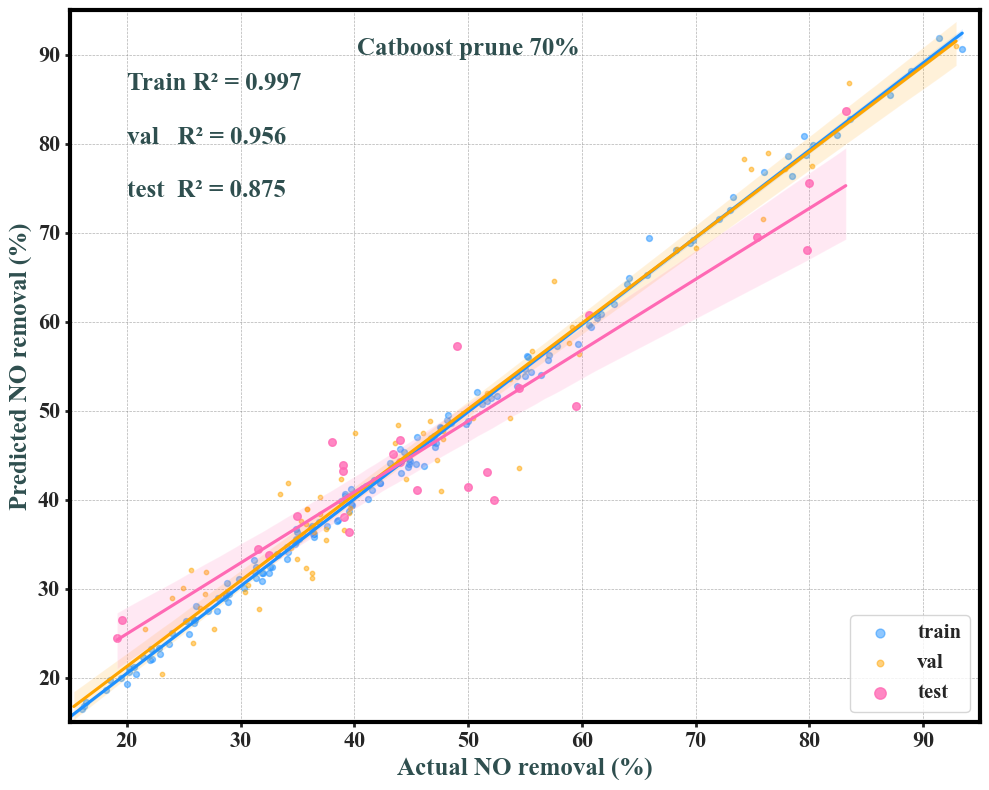

In [17]:
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "Catboost prune 70%", actual_text='Actual NO removal (%)',test_lower=None,test_upper=None,pred_text='Predicted NO removal (%)',save=True)

cv train R2: -0.242 (+/- 0.506) 

cv train R2: -0.242 (+/- 0.506) 

XGB Train 70% mse: 0.00050 | rmse: 0.02245 | mae: 0.01759 | mape: 4.53382 | smape: 4.44286 | r2: 0.98487

XGB val 30% mse: 0.00176 | rmse: 0.04198 | mae: 0.03388 | mape: 8.78822 | smape: 8.57712 | r2: 0.94077

XGB test mse: 0.00487 | rmse: 0.06981 | mae: 0.05179 | mape: 11.85107 | smape: 11.88340 | r2: 0.83048

测试图已保存：prune1\XGBboost prune 70%.jpg


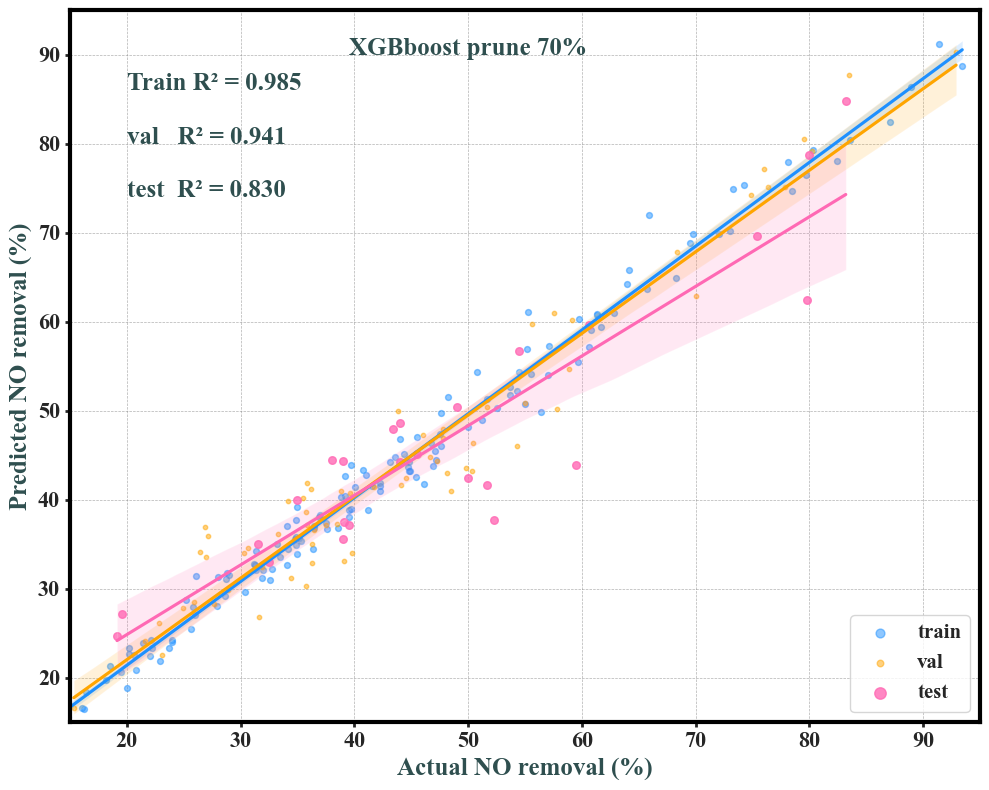

In [22]:
df_b = df.loc[remove_b[21]]
X_train_val = df_b.drop(columns=['NO(%)'])
y_train_val = df_b['NO(%)']
df_b_val = df.loc[b_test_70]
X_val = df_b_val.drop(columns=['NO(%)'])
y_val = df_b_val['NO(%)']
train_pred, val_pred = process_regressor(model[b],X_train_val,X_val,y_train_val,y_val)
_,test_pred = process_regressor(model[b],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('XGB Train 70%', y_train_val, train_pred)
model_performance_metrics('XGB val 30%', y_val, val_pred)
model_performance_metrics('XGB test', y_test, test_pred)
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "XGBboost prune 70%", actual_text='Actual NO removal (%)',test_lower=None,test_upper=None,pred_text='Predicted NO removal (%)',save=True)

cv train R2: -0.040 (+/- 0.205) 

cv train R2: -0.040 (+/- 0.205) 

GradientBoost Train 70% mse: 0.00001 | rmse: 0.00297 | mae: 0.00240 | mape: 0.60969 | smape: 0.60825 | r2: 0.99974

GradientBoost val 30% mse: 0.00122 | rmse: 0.03486 | mae: 0.02730 | mape: 7.28709 | smape: 7.11885 | r2: 0.95537

GradientBoost test mse: 0.00388 | rmse: 0.06225 | mae: 0.05150 | mape: 11.16115 | smape: 11.07314 | r2: 0.86522

测试图已保存：prune1\GradientBoost prune 70%.jpg


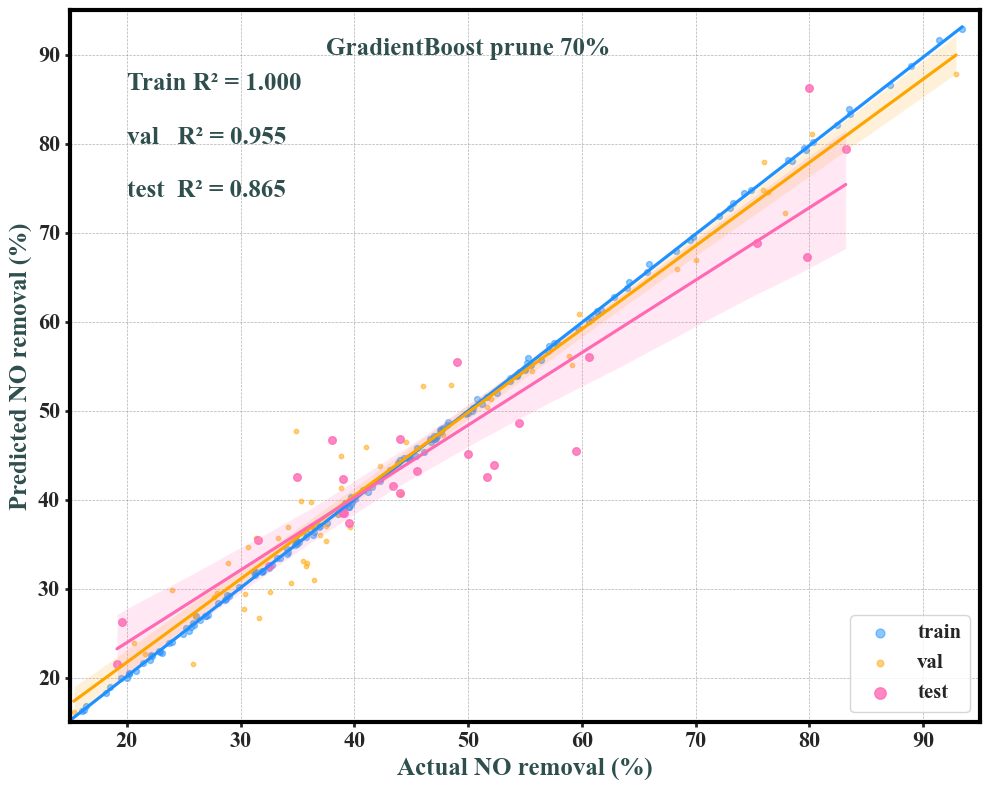

In [23]:
df_c = df.loc[remove_c[20]]
X_train_val = df_c.drop(columns=['NO(%)'])
y_train_val = df_c['NO(%)']
df_c_val = df.loc[c_test_70]
X_val = df_c_val.drop(columns=['NO(%)'])
y_val = df_c_val['NO(%)']
train_pred, val_pred = process_regressor(model[c],X_train_val,X_val,y_train_val,y_val,cv=True)
_,test_pred = process_regressor(model[c],X_train_val,X_test,y_train_val,y_test,cv=True)
model_performance_metrics('GradientBoost Train 70%', y_train_val, train_pred)
model_performance_metrics('GradientBoost val 30%', y_val, val_pred)
model_performance_metrics('GradientBoost test', y_test, test_pred)
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "GradientBoost prune 70%", actual_text='Actual NO removal (%)',test_lower=None,test_upper=None,pred_text='Predicted NO removal (%)',save=True)